In [1]:
from CaFAnalysis import PlotStyle, PlottingTools
PlotStyle.set_plot_style()
import cu_rsc as cr
cr.setup_tables()
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from tqdm import tqdm
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

### Ref

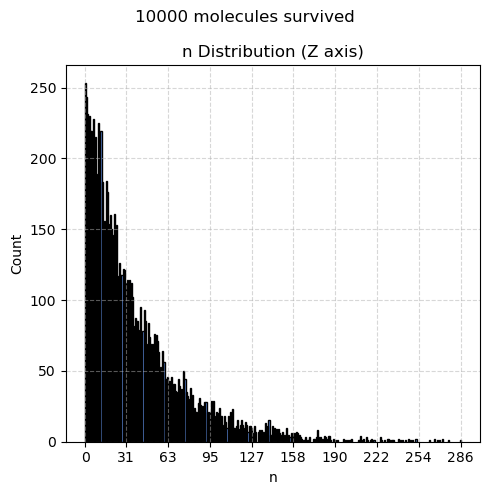

Survival rate: 1.00±0.00e+00
n_bar X: 6.50±2.24e-03
n_bar Y: 7.51±2.50e-03
n_bar Z: 38.15±1.19e-02
fraction of n_{x,y}=0,n_z=0,1: 0.0005


In [15]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
print(f"Survival rate: {result["survival_rate_mean"]:.2f}\u00B1{result["survival_rate_sem"]:.2e}")
print(f"n_bar X: {result["mot_mean"][0]:.2f}\u00B1{result["mot_sem"][0]:.2e}")
print(f"n_bar Y: {result["mot_mean"][1]:.2f}\u00B1{result["mot_sem"][1]:.2e}")
print(f"n_bar Z: {result["mot_mean"][2]:.2f}\u00B1{result["mot_sem"][2]:.2e}")
count = np.sum((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))
print(r"fraction of n_{x,y}=0,n_z=0,1:", count/mol_0.shape[0])

### Optimized

In [3]:
seq_op = np.load("seq_op.npy")

In [8]:
len(seq_op)

189

In [17]:
np.unique(seq_op, axis=0)

array([[ 0.00000000e+00, -3.00000000e+00,  1.84187616e+04,
         7.63928164e-05],
       [ 0.00000000e+00, -2.00000000e+00,  1.45368382e+04,
         9.39173207e-05],
       [ 0.00000000e+00, -1.00000000e+00,  7.84287242e+03,
         1.34476841e-04],
       [ 1.00000000e+00, -3.00000000e+00,  1.85722610e+04,
         7.00206985e-05],
       [ 1.00000000e+00, -2.00000000e+00,  1.18053453e+04,
         1.04600718e-04],
       [ 1.00000000e+00, -1.00000000e+00,  5.65819742e+03,
         1.58817067e-04],
       [ 2.00000000e+00, -6.00000000e+00,  1.00000000e+04,
         4.91887879e-05],
       [ 2.00000000e+00, -5.00000000e+00,  1.00000000e+04,
         1.46294961e-04],
       [ 2.00000000e+00, -4.00000000e+00,  5.03915688e+03,
         1.15801219e-04],
       [ 2.00000000e+00, -3.00000000e+00,  2.26278639e+03,
         1.86457720e-04],
       [ 2.00000000e+00, -2.00000000e+00,  3.99946633e+03,
         2.20509975e-04]])

Raman pulses: 100%|██████████| 189/189 [00:14<00:00, 13.28it/s]


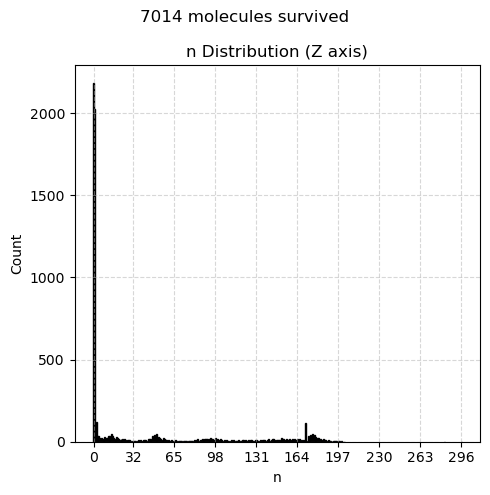

Survival rate: 0.70±1.43e-04
n_bar X: 0.94±1.42e-03
n_bar Y: 1.05±1.59e-03
n_bar Z: 37.20±2.30e-02
fraction of n_{x,y}=0,n_z=0,1: 0.4004


In [9]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)
cr.raman_cool_with_pumping(mol_0, seq_op, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
print(f"Survival rate: {result["survival_rate_mean"]:.2f}\u00B1{result["survival_rate_sem"]:.2e}")
print(f"n_bar X: {result["mot_mean"][0]:.2f}\u00B1{result["mot_sem"][0]:.2e}")
print(f"n_bar Y: {result["mot_mean"][1]:.2f}\u00B1{result["mot_sem"][1]:.2e}")
print(f"n_bar Z: {result["mot_mean"][2]:.2f}\u00B1{result["mot_sem"][2]:.2e}")
count = np.sum((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))
print(r"fraction of n_{x,y}=0,n_z=0,1:", count/mol_0.shape[0])

In [4]:
def to_cpu(x):
    return x.get() if hasattr(x, "get") else x
def bootstrap_fraction(mask, n_boot=200):
    mask = to_cpu(mask).astype(np.float64)
    n = len(mask)
    boot_means = np.empty(n_boot, dtype=np.float64)
    for b in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        boot_means[b] = mask[idx].mean()
    return boot_means.mean(), boot_means.std(ddof=1)
    

In [5]:
results = []

temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)

chunk_size = 10
n_pulses = len(seq_op)

for i in tqdm(range(0, n_pulses, chunk_size)):
    pulse_block = seq_op[i:i+chunk_size]

    cr.raman_cool_with_pumping(
        mol_0,
        pulse_block,
        res,
        show_progress=False
    )

    result = cr.bootstrap_stats_from_molecules(mol_0)
    ground_like_mask = ((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))

    frac_ground_like_mean, frac_ground_like_sem = bootstrap_fraction(ground_like_mask)
    
    results.append({
        "pulse_idx": i + len(pulse_block),
        "survival_rate_mean": to_cpu(result["survival_rate_mean"]),
        "survival_rate_sem": to_cpu(result["survival_rate_sem"]),
        "nbar_x_mean": to_cpu(result["mot_mean"][0]),
        "nbar_x_sem": to_cpu(result["mot_sem"][0]),
        "nbar_y_mean": to_cpu(result["mot_mean"][1]),
        "nbar_y_sem": to_cpu(result["mot_sem"][1]),
        "nbar_z_mean": to_cpu(result["mot_mean"][2]),
        "nbar_z_sem": to_cpu(result["mot_sem"][2]),
        "frac_nx0_ny0_nz01_mean": frac_ground_like_mean,
        "frac_nx0_ny0_nz01_sem": frac_ground_like_sem,
    })

# Convert to arrays
pulse_arr = np.array([r["pulse_idx"] for r in results])

survival_mean = np.array([r["survival_rate_mean"] for r in results])
survival_sem  = np.array([r["survival_rate_sem"] for r in results])

nbar_x_mean = np.array([r["nbar_x_mean"] for r in results])
nbar_x_sem  = np.array([r["nbar_x_sem"] for r in results])

nbar_y_mean = np.array([r["nbar_y_mean"] for r in results])
nbar_y_sem  = np.array([r["nbar_y_sem"] for r in results])

nbar_z_mean = np.array([r["nbar_z_mean"] for r in results])
nbar_z_sem  = np.array([r["nbar_z_sem"] for r in results])

frac_ground_mean = np.array([r["frac_nx0_ny0_nz01_mean"] for r in results])
frac_ground_err = np.array([r["frac_nx0_ny0_nz01_sem"] for r in results])

100%|██████████| 19/19 [00:32<00:00,  1.72s/it]


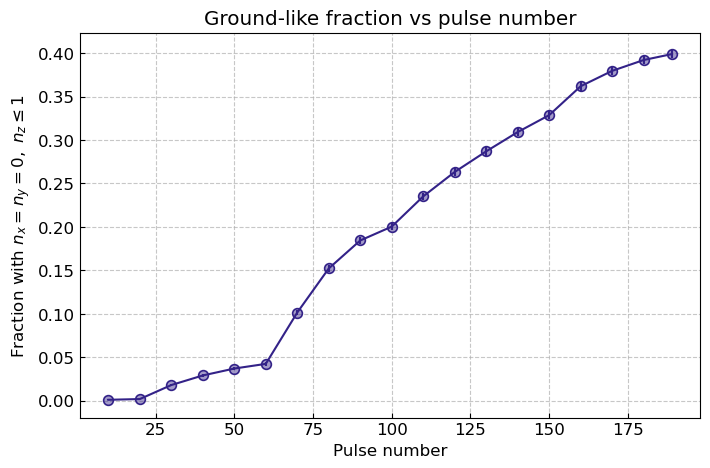

In [12]:
PlotStyle
plt.figure(figsize=(8, 5))
plt.errorbar(pulse_arr, frac_ground_mean, frac_ground_err, fmt='o-')
plt.xlabel("Pulse number")
plt.ylabel(r"Fraction with $n_x=n_y=0,\ n_z\leq 1$")
plt.title(r"Ground-like fraction vs pulse number")
plt.grid(True)
plt.show()

np.savez("frac_op.npz", pulse_arr=pulse_arr, frac_ground_mean=frac_ground_mean, frac_ground_err=frac_ground_err)

### Exp

In [2]:
seq_exp = np.load("seq_exp.npy")

In [12]:
seq_exp.shape

(280, 4)

In [19]:
np.unique(seq_exp, axis=0)

array([[ 0.00000000e+00, -3.00000000e+00,  2.45060364e+04,
         7.00000000e-05],
       [ 0.00000000e+00, -2.00000000e+00,  2.45060364e+04,
         7.00000000e-05],
       [ 0.00000000e+00, -1.00000000e+00,  1.36588502e+04,
         5.00000000e-05],
       [ 1.00000000e+00, -3.00000000e+00,  1.68208398e+04,
         7.00000000e-05],
       [ 1.00000000e+00, -2.00000000e+00,  1.68208398e+04,
         7.00000000e-05],
       [ 1.00000000e+00, -1.00000000e+00,  9.93243171e+03,
         5.00000000e-05],
       [ 2.00000000e+00, -5.00000000e+00,  4.58400345e+03,
         5.00000000e-05],
       [ 2.00000000e+00, -4.00000000e+00,  4.58400345e+03,
         5.00000000e-05],
       [ 2.00000000e+00, -3.00000000e+00,  2.36040951e+03,
         2.00000000e-04],
       [ 2.00000000e+00, -2.00000000e+00,  2.36040951e+03,
         2.00000000e-04],
       [ 2.00000000e+00, -1.00000000e+00,  2.36040951e+03,
         2.00000000e-04]])

Raman pulses: 100%|██████████| 280/280 [00:20<00:00, 13.75it/s]


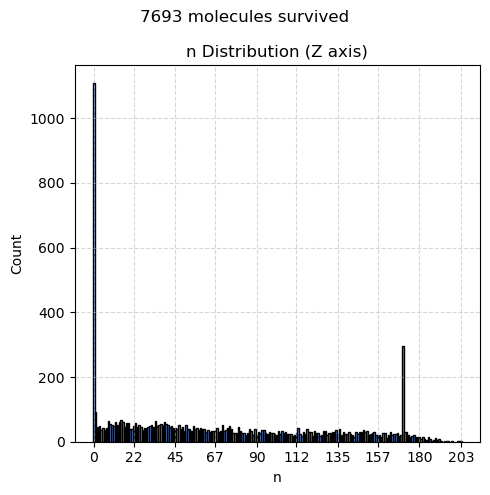

Survival rate: 0.77±1.32e-04
n_bar X: 0.22±4.45e-04
n_bar Y: 0.37±8.63e-04
n_bar Z: 69.20±2.03e-02
fraction of n_{x,y}=0,n_z=0,1: 0.1148


In [14]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)
cr.raman_cool_with_pumping(mol_0, seq_exp, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
print(f"Survival rate: {result["survival_rate_mean"]:.2f}\u00B1{result["survival_rate_sem"]:.2e}")
print(f"n_bar X: {result["mot_mean"][0]:.2f}\u00B1{result["mot_sem"][0]:.2e}")
print(f"n_bar Y: {result["mot_mean"][1]:.2f}\u00B1{result["mot_sem"][1]:.2e}")
print(f"n_bar Z: {result["mot_mean"][2]:.2f}\u00B1{result["mot_sem"][2]:.2e}")
count = np.sum((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))
print(r"fraction of n_{x,y}=0,n_z=0,1:", count/mol_0.shape[0])

In [15]:
results = []

temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)

chunk_size = 10
n_pulses = len(seq_exp) - 80

for i in tqdm(range(0, n_pulses, chunk_size)):
    pulse_block = seq_exp[i:i+chunk_size]

    cr.raman_cool_with_pumping(
        mol_0,
        pulse_block,
        res,
        show_progress=False
    )

    result = cr.bootstrap_stats_from_molecules(mol_0)
    ground_like_mask = ((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))

    frac_ground_like_mean, frac_ground_like_sem = bootstrap_fraction(ground_like_mask)
    
    results.append({
        "pulse_idx": i + len(pulse_block),
        "survival_rate_mean": to_cpu(result["survival_rate_mean"]),
        "survival_rate_sem": to_cpu(result["survival_rate_sem"]),
        "nbar_x_mean": to_cpu(result["mot_mean"][0]),
        "nbar_x_sem": to_cpu(result["mot_sem"][0]),
        "nbar_y_mean": to_cpu(result["mot_mean"][1]),
        "nbar_y_sem": to_cpu(result["mot_sem"][1]),
        "nbar_z_mean": to_cpu(result["mot_mean"][2]),
        "nbar_z_sem": to_cpu(result["mot_sem"][2]),
        "frac_nx0_ny0_nz01_mean": frac_ground_like_mean,
        "frac_nx0_ny0_nz01_sem": frac_ground_like_sem,
    })

# Convert to arrays
pulse_arr = np.array([r["pulse_idx"] for r in results])

survival_mean = np.array([r["survival_rate_mean"] for r in results])
survival_sem  = np.array([r["survival_rate_sem"] for r in results])

nbar_x_mean = np.array([r["nbar_x_mean"] for r in results])
nbar_x_sem  = np.array([r["nbar_x_sem"] for r in results])

nbar_y_mean = np.array([r["nbar_y_mean"] for r in results])
nbar_y_sem  = np.array([r["nbar_y_sem"] for r in results])

nbar_z_mean = np.array([r["nbar_z_mean"] for r in results])
nbar_z_sem  = np.array([r["nbar_z_sem"] for r in results])

frac_ground_mean = np.array([r["frac_nx0_ny0_nz01_mean"] for r in results])
frac_ground_err = np.array([r["frac_nx0_ny0_nz01_sem"] for r in results])

100%|██████████| 20/20 [00:33<00:00,  1.66s/it]


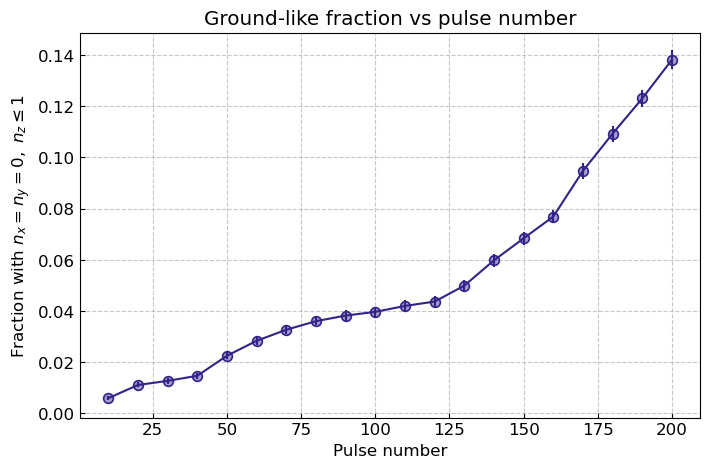

In [16]:
plt.figure(figsize=(8, 5))
plt.errorbar(pulse_arr, frac_ground_mean, frac_ground_err, fmt='o-')
plt.xlabel("Pulse number")
plt.ylabel(r"Fraction with $n_x=n_y=0,\ n_z\leq 1$")
plt.title(r"Ground-like fraction vs pulse number")
plt.grid(True)
plt.show()

np.savez("frac_exp.npz", pulse_arr=pulse_arr, frac_ground_mean=frac_ground_mean, frac_ground_err=frac_ground_err)

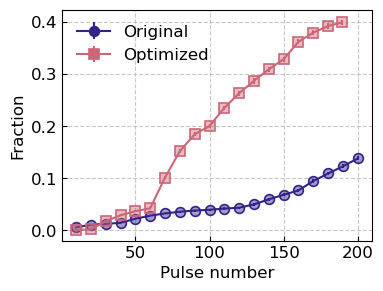

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
exp = np.load("frac_exp.npz")
op  = np.load("frac_op.npz")

pulse_exp = exp["pulse_arr"]
mean_exp  = exp["frac_ground_mean"]
err_exp   = exp["frac_ground_err"]

pulse_op = op["pulse_arr"]
mean_op  = op["frac_ground_mean"]
err_op   = op["frac_ground_err"]

# Plot
plt.figure(figsize=(4, 3))

plt.errorbar(
    pulse_exp, mean_exp, yerr=err_exp,
    fmt='o-', label="Original"
)

plt.errorbar(
    pulse_op, mean_op, yerr=err_op,
    fmt='s-', label="Optimized"
)

plt.xlabel("Pulse number")
plt.ylabel(r"Fraction")
plt.legend(frameon=False)
plt.savefig("RSC_comparison.pdf", bbox_inches="tight")
plt.show()

### RST

In [14]:
zt_freqs = cp.linspace(-30e3, 30e3, 1000)
zt_rabi = 1.01e3
zt_pulse = 500e-6
trap_detuning_sigma = 0.5e3
carrier_detuning_sigma = 0.5e3
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(
    10000, temp, 
    trap_detuning_sigma=trap_detuning_sigma,
    carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_0, seq_exp[:-80], res, show_progress=True)


frequencys, polarizations_exp = cr.raman_sideband_thermometry(
    molecules_dev=mol_0,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

mol_0 = cr.build_thermal_molecules(
    10000, temp, 
    trap_detuning_sigma=trap_detuning_sigma,
    carrier_detuning_sigma=carrier_detuning_sigma)
cr.raman_cool_with_pumping(mol_0, seq_op, res, show_progress=True)

frequencys, polarizations_opt = cr.raman_sideband_thermometry(
    molecules_dev=mol_0,
    axis=2,
    frequencys=zt_freqs,
    rabi_freq=zt_rabi,
    pulse_time=zt_pulse,
    res=res,
    k_max=2
)

Raman thermometry: 100%|██████████| 1000/1000 [00:06<00:00, 145.99it/s]


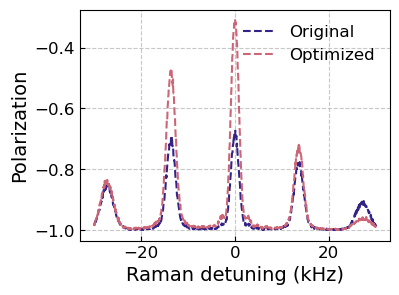

In [15]:
plt.figure(figsize=(4,3))
plt.plot(
    -cp.asnumpy(frequencys*1e-3), 
    cp.asnumpy(polarizations_exp), 
    '--',
    label='Original')
plt.plot(
    -cp.asnumpy(frequencys*1e-3), 
    cp.asnumpy(polarizations_opt), 
    '--',
    label='Optimized')

plt.xlabel("Raman detuning (kHz)", fontsize=14)
plt.ylabel("Polarization", fontsize=14)
plt.legend(frameon=False)
plt.savefig("RST_comparison.pdf", bbox_inches="tight")